In [2]:
suppressPackageStartupMessages(library(tibble))
suppressPackageStartupMessages(library(rWikiPathways))
suppressPackageStartupMessages(library("FactoMineR"))
suppressPackageStartupMessages(library(fgsea))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(GSA))
suppressPackageStartupMessages(library(clustifyr))
suppressPackageStartupMessages(library(fgsea))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(factoextra))
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(grid))
suppressPackageStartupMessages(library(shadowtext))
suppressPackageStartupMessages(library(gridExtra))
suppressPackageStartupMessages(library(lattice))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(GSEABase))
suppressPackageStartupMessages(library(GSVA))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(matrixStats))
suppressPackageStartupMessages(library(org.Hs.eg.db))
suppressPackageStartupMessages(library(AnnotationDbi) )
suppressPackageStartupMessages(library(limma))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(tidyverse))

suppressPackageStartupMessages(library(tictoc))
suppressPackageStartupMessages(library(dplyr))

In [3]:
### functions
## this function will create our grn file and run correlation analysis --- use to filter connections based off 
## correlations but we no longer do that
GRN <- function(dataset, anno, remove_zero, log_scale, cut_off){ 
    keep1 = (as.character(anno$TF) %in% rownames(dataset))
    keep2 = (as.character(anno$gene) %in% rownames(dataset))
    A1 = anno[keep1 & keep2,]
    
    all_gene = unique(c(as.character(A1$TF),as.character(A1$gene)))
    dataset = dataset[rownames(dataset) %in% all_gene,]
    gene_data = rownames(dataset)
    
    if (log_scale){
       dataset = log(dataset + 1)
       cut_off = log(cut_off + 1)
    }
    
    SP = matrix(1,dim(A1)[1],4)
    colnames(SP) = c('TF2gene_pearson_s','TF2gene_pearson_p','TF2gene_spearman_s','TF2gene_spearman_p')
    TF_all = as.character(A1$TF)
    gene_all = as.character(A1$gene)
    
    if (remove_zero == FALSE){
       for (i in 1:dim(A1)[1]){
        TF_temp = TF_all[i]
        gene_temp = gene_all[i]
        TF_exp_temp = dataset[gene_data == TF_temp,] 
        gene_exp_temp = dataset[gene_data == gene_temp,]

        temp = suppressWarnings(cor.test(TF_exp_temp,gene_exp_temp,method = "pearson"))
        SP[i,1] = temp$estimate
        SP[i,2] = temp$p.value

        temp = suppressWarnings(cor.test(TF_exp_temp,gene_exp_temp,method = "spearman"))
        SP[i,3] = temp$estimate
        SP[i,4] = temp$p.value
        } 
    }
    
    if (remove_zero == TRUE){
       for (i in 1:dim(A1)[1]){
        TF_temp = TF_all[i]
        gene_temp = gene_all[i]
        TF_exp_temp = dataset[gene_data == TF_temp,]
        gene_exp_temp = dataset[gene_data == gene_temp,]
        
        keep_use = ((TF_exp_temp>cut_off) & (gene_exp_temp>cut_off))
        TF_exp_temp = TF_exp_temp[keep_use]
        gene_exp_temp = gene_exp_temp[keep_use]
        
        if (length(gene_exp_temp)>0.5*dim(dataset)[2]){
            temp = suppressWarnings(cor.test(TF_exp_temp,gene_exp_temp,method = "pearson"))
            SP[i,1] = temp$estimate
            SP[i,2] = temp$p.value

            temp = suppressWarnings(cor.test(TF_exp_temp,gene_exp_temp,method = "spearman"))
            SP[i,3] = temp$estimate
            SP[i,4] = temp$p.value 
        }
        } 
    }
    
    pearson_FDR = p.adjust(SP[,2], method = "BH", n = length(SP[,2]))
    spearman_FDR = p.adjust(SP[,4], method = "BH", n = length(SP[,4]))
    SP = as.data.frame(SP)
    
    SP$pearson_FDR = pearson_FDR
    SP$spearman_FDR = spearman_FDR
    SP1 = cbind(A1,SP)
    return (SP1)
}

# Create TF-gene links using Gaowei's GRN code 

In [3]:
### first run GRN for each cell type
#cell_type_use = c('Acinar_1_2_6','Acinar_3','Acinar_4','Acinar_5','Activated_Stellate','Alpha','Bcells','Beta','Delta','Ductal','Endothelial','LymphEndo','Macrophage','Mast','Quiescent_Stellate','Tcells')

cell_type_use = c('Acinar_1_2_6','Acinar_3','Acinar_4','Acinar_5','Activated_Stellate','Alpha','Beta','Ductal','Endothelial','Macrophage','Quiescent_Stellate','Tcells')
#cell_type_use = 'Beta'
#for (cell_num in 15:length(cell_type_use)){

for (cell_num in 1:length(cell_type_use)){
    #print cell type working on
    print(paste0("Working on: ",cell_type_use[cell_num]))
    
    #create needed directories
    mainDir <- '/nfs/lab/projects/nPOD/downstream_files/GRN'
    subDir <- paste0(cell_type_use[cell_num],'/')
    print(file.path(mainDir, subDir))
    dir.create(file.path(mainDir, subDir))
    
    #move to that directory
    setwd(file.path(mainDir, subDir))
    
    #read in atac related items
    A = read.csv('/nfs/lab/rlmelton/npod/GRN/RecapitulateData/TF_peak_gene.csv')
    ATAC_file = paste0('/nfs/lab/projects/nPOD/downstream_files/ATAC/pseudobulk_nPODids/fixed_peak/merge_fixedPeak_mtx/pseudobulk_matrices/',cell_type_use[cell_num],'_pseudobulk_matrix_fixedPeak.txt')
    ATAC_norm=read.table(ATAC_file,check.names=FALSE)
    removed_samples <- c('multi_6220','multi_6228','multi_6229','multi_6234','multi_6236','multi_6267',
        'multi_6362','multi_6375','6278')
    ATAC_norm <- ATAC_norm[,!colnames(ATAC_norm) %in% removed_samples]
    
    peak_id = rownames(ATAC_norm)
    peak_id1 = peak_id
    for (i in 1:length(peak_id)){
        temp = strsplit(peak_id[i],split = '-')[[1]]
        peak_id1[i] = paste0('chr',temp[1],':',temp[2],'-',temp[3])
    }
    rownames(ATAC_norm) = peak_id1
    
    #filter atac count matrix to peaks with gene links
    A1 = A[A$peak %in% rownames(ATAC_norm),]
    
    #read in binary table of peaks by celltype
    Peak = read.csv('/nfs/lab/rlmelton/npod/GRN/T1D_GRN/peak/snATAC_peak.csv')
    Peak1 = as.matrix(Peak[,-1])
    Peak_all = as.character(Peak$X)
    peak_bool = Peak1[,colnames(Peak1)==cell_type_use[cell_num]]
    
    #keep only peaks found in that cell type
    Peak_cell = Peak_all[peak_bool>0]

    ATAC_norm = ATAC_norm[(rownames(ATAC_norm) %in% Peak_cell),]
    
    #remove peaks with 0 counts
    ATAC_norm = ATAC_norm[,colSums(ATAC_norm)>0]
    
    dim(ATAC_norm)
    Meta = read.table('/nfs/lab/rlmelton/npod/nPOD_clinical_July2022_metadata.txt',sep = '\t',header = TRUE)
    sample_id = as.character(Meta$Sample.ID)

    #sample_id = paste0('',as.character(Meta$Sample.ID))
    ATAC_id = as.character(Meta$Sample.ID)
    ATAC_norm = ATAC_norm[,colnames(ATAC_norm) %in% ATAC_id]
    
    #ATAC_norm <- as.data.frame(do.call(cbind, by(t(ATAC_norm),INDICES=names(ATAC_norm),FUN=colSums)))

    temp = ATAC_norm
    
    #normalize atac counts
    for (i in 1:dim(temp)[2]){
        ATAC_norm[,i] = (temp[,i]/sum(temp[,i]))*1000000
    }
    
    #read in gene expression data
   RNA_file = paste0('/nfs/lab/projects/nPOD/downstream_files/RNA/PseudobulkMatrices/SoupX/TPM_min20CellsMtx/',cell_type_use[cell_num],'.min20cell.TPM.perCellType_SoupX.txt')
   RNA=read.table(RNA_file, check.names=FALSE)
   RNA_norm = as.matrix(RNA)
   rownames(RNA_norm) = rownames(RNA)
    # remove genes with 0 counts
   RNA_norm = RNA_norm[,colSums(RNA_norm)>0]
 
   sample_id = as.character(Meta$Sample.ID)
   RNA_id = as.character(Meta$Sample.ID)

    RNA_norm = RNA_norm[,colnames(RNA_norm) %in% RNA_id]

    head(RNA_norm)
   #RNA_norm <- as.data.frame(do.call(cbind, by(t(RNA_norm),INDICES=names(RNA_norm),FUN=colSums)))
 
  donor_use = intersect(colnames(RNA_norm),colnames(ATAC_norm))
  RNA_norm1 = RNA_norm[,colnames(RNA_norm) %in% donor_use]
  RNA_norm1 = RNA_norm1[,sort(colnames(RNA_norm1))]
  ATAC_norm1 = ATAC_norm[,(colnames(ATAC_norm) %in% donor_use)]
  ATAC_norm1 = ATAC_norm1[,sort(colnames(ATAC_norm1))]
  dim(ATAC_norm1)
  dim(RNA_norm1)
  all(colnames(RNA_norm1)==colnames(ATAC_norm1))
#  
  RNA_norm1 = RNA_norm1[rowMeans(RNA_norm1)>0,]
  ATAC_norm1 = ATAC_norm1[rowMeans(ATAC_norm1)>0,]
#  
  keep_TF = (A1$TF %in% rownames(RNA_norm1))
  keep_gene = (A1$gene %in% rownames(RNA_norm1))
  keep_peak = (A1$peak %in% rownames(ATAC_norm1))
  keep_celltype = (as.character(A1$cell_type) %in% c(cell_type_use[cell_num],'all'))
  keep_ABC = (as.character(A1$type) =='ABC' & as.numeric(A1$score_distance)>0.015)
  keep_proximal = (as.character(A1$type) =='proximal')

  A2 = A1[(keep_TF & keep_gene & keep_celltype & (keep_ABC | keep_proximal) & keep_peak),]
  A3 = A2[!duplicated(A2[,c(2,3,4)]),]
#
  a = GRN(RNA_norm1, A3,FALSE,FALSE, 0)
    #Out_file = paste0('/nfs/lab/rlmelton/npod/GRN/23may23/',cell_type_use[cell_num],'_TF_gene.csv')

  Out_file = paste0(cell_type_use[cell_num],'_TF_gene.csv')
  write.csv(a,Out_file)

}


[1] "Working on: Acinar_1_2_6"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Acinar_1_2_6/"
[1] "Working on: Acinar_3"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Acinar_3/"
[1] "Working on: Acinar_4"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Acinar_4/"
[1] "Working on: Acinar_5"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Acinar_5/"
[1] "Working on: Activated_Stellate"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Activated_Stellate/"
[1] "Working on: Alpha"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Alpha/"
[1] "Working on: Beta"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Beta/"
[1] "Working on: Ductal"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Ductal/"
[1] "Working on: Endothelial"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Endothelial/"
[1] "Working on: Macrophage"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Macrophage/"
[1] "Working on: Quiescent_Stellate"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Quiescent_Stellate/"
[1]

# Filter TF-gene links to modules with # genes < 90% percentile 

[1] "Acinar_1_2_6"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Acinar_1_2_6/"


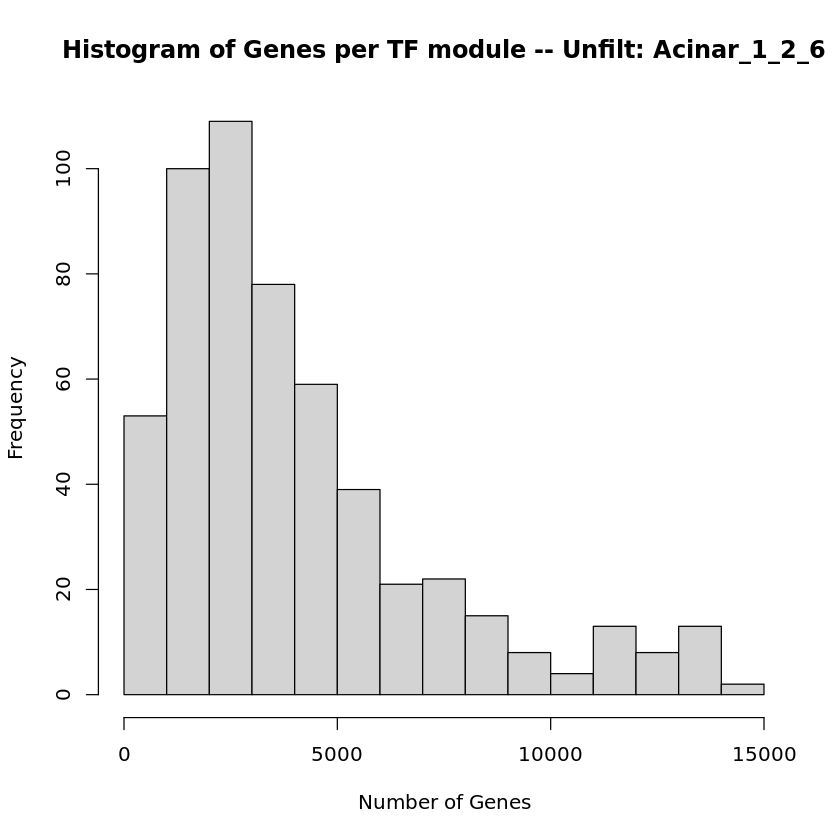

[1] 241
[1] 8362
[1] 3213.497
[1] "Acinar_3"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Acinar_3/"


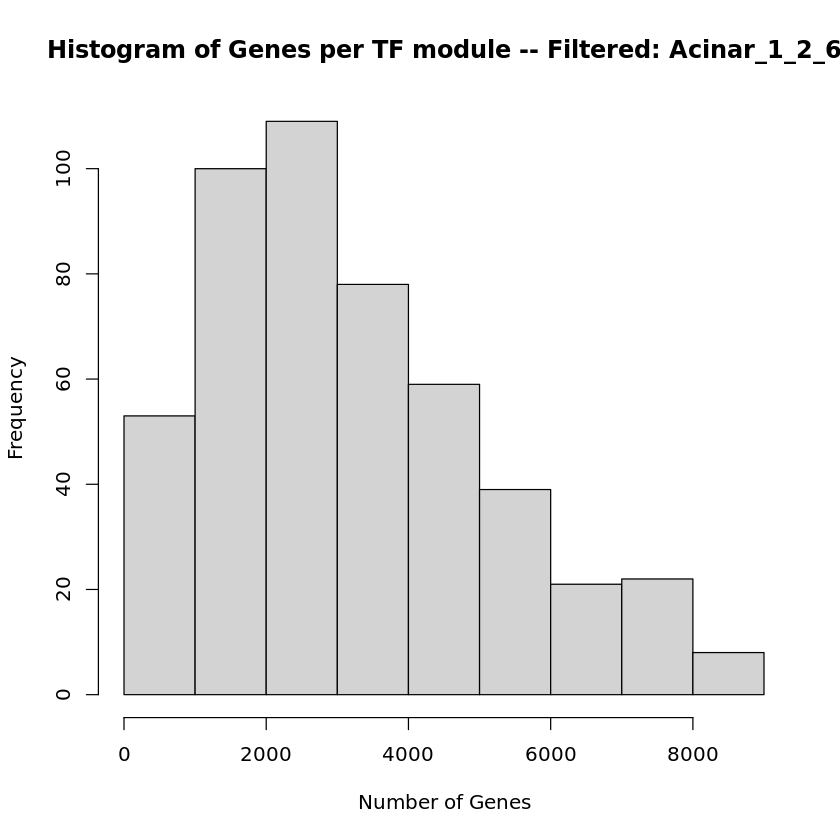

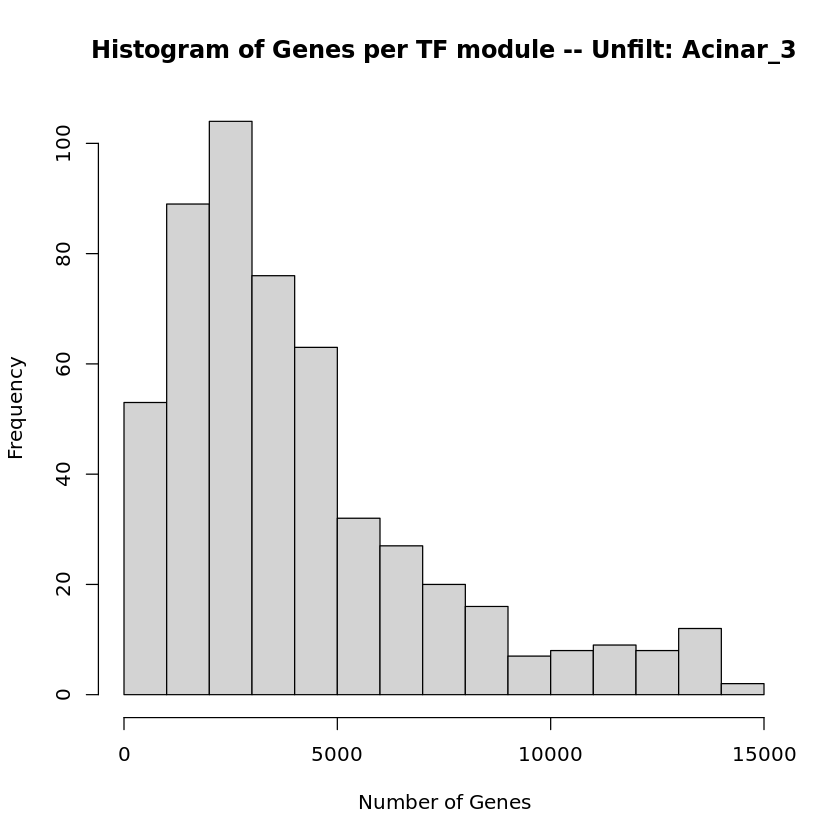

[1] 244
[1] 8288
[1] 3273.159
[1] "Acinar_4"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Acinar_4/"


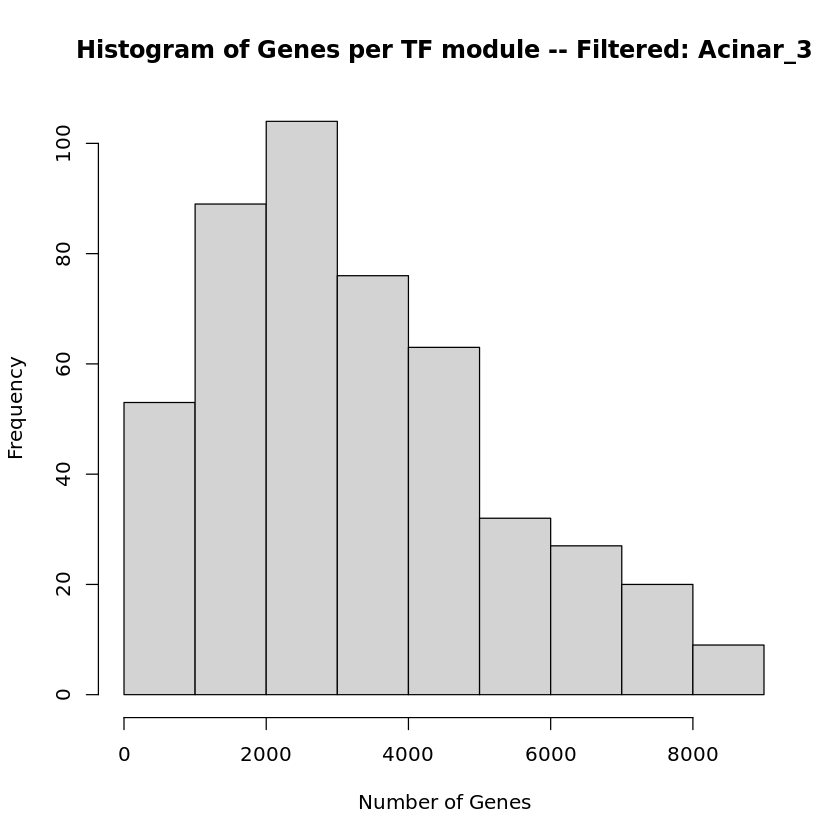

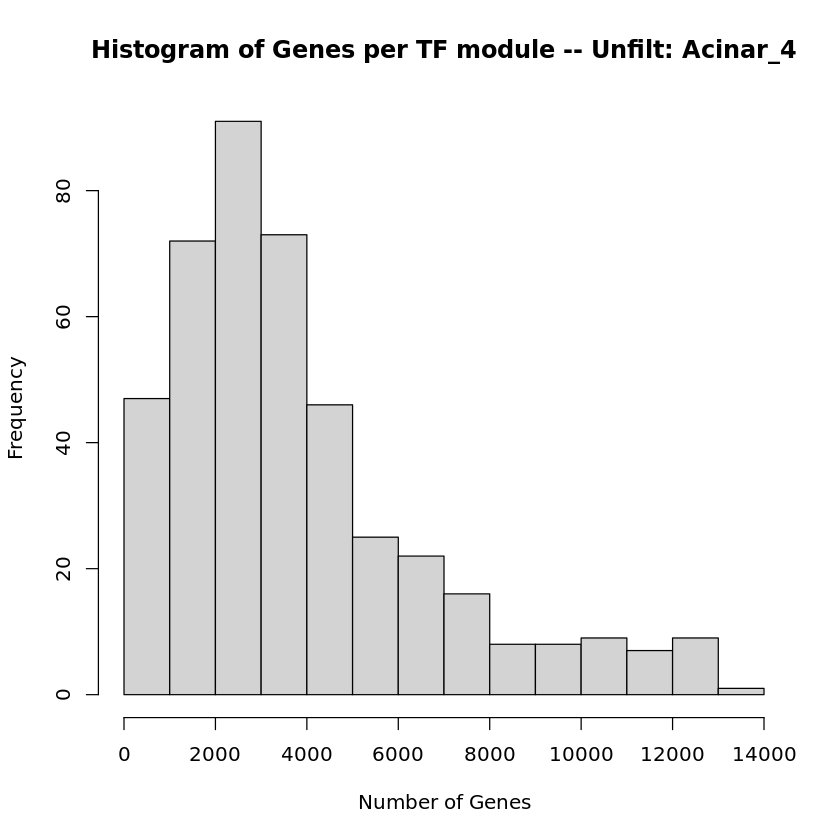

[1] 231
[1] 7729
[1] 3099.141
[1] "Acinar_5"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Acinar_5/"


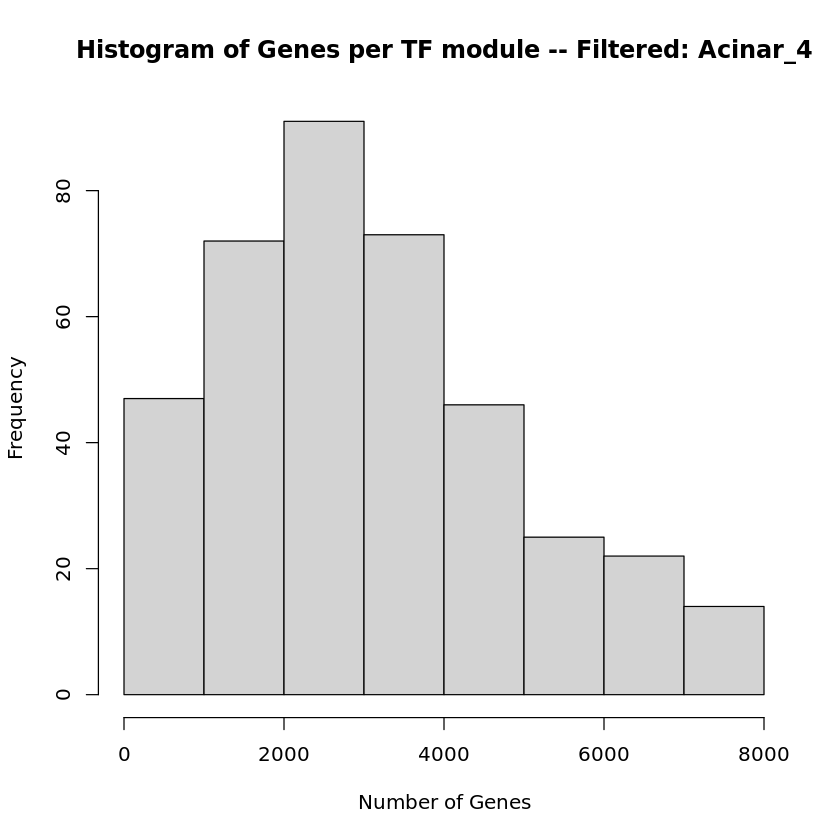

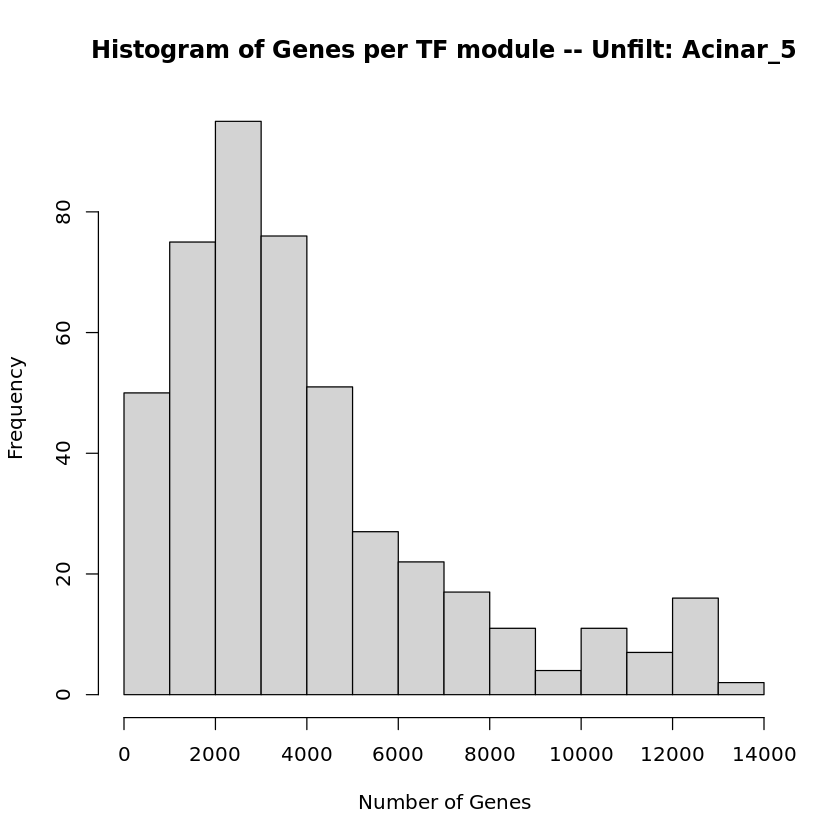

[1] 244
[1] 8223
[1] 3179.432
[1] "Activated_Stellate"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Activated_Stellate/"


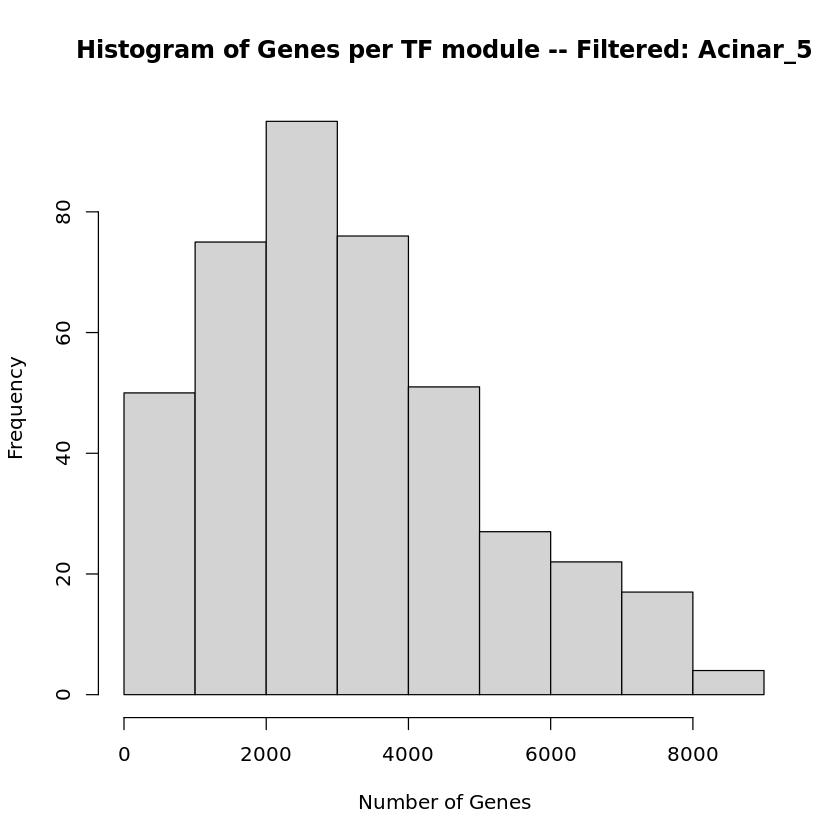

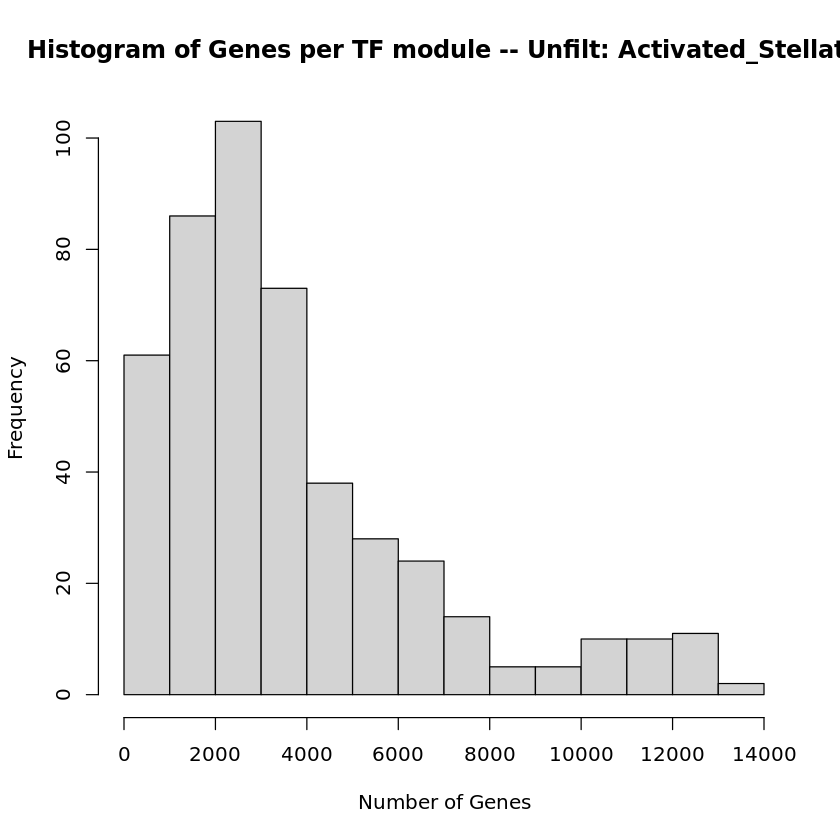

[1] 259
[1] 7629
[1] 2911.258
[1] "Alpha"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Alpha/"


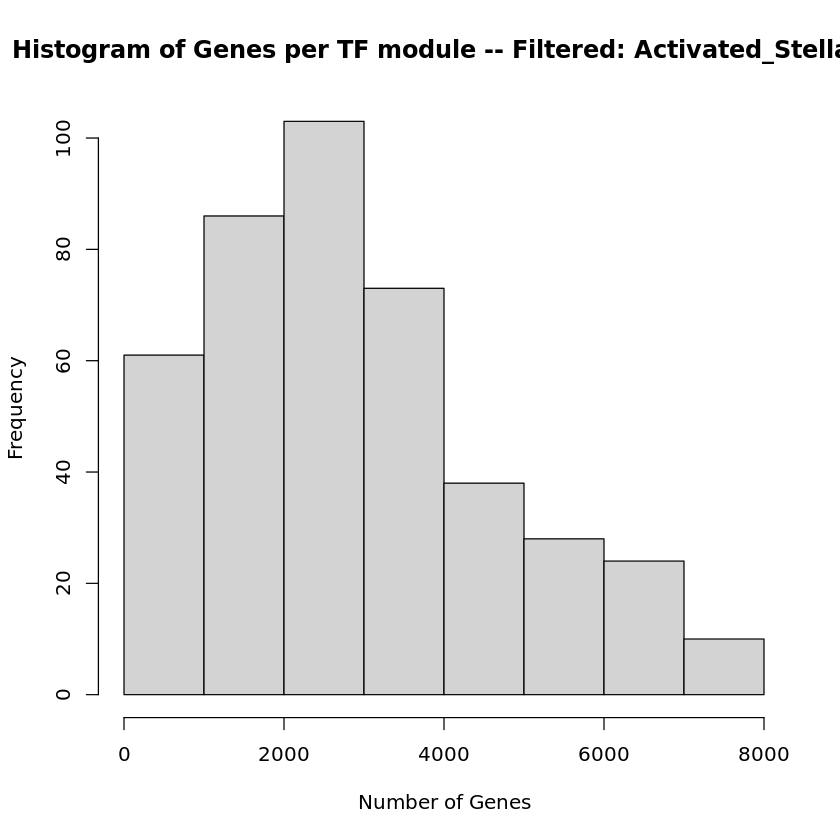

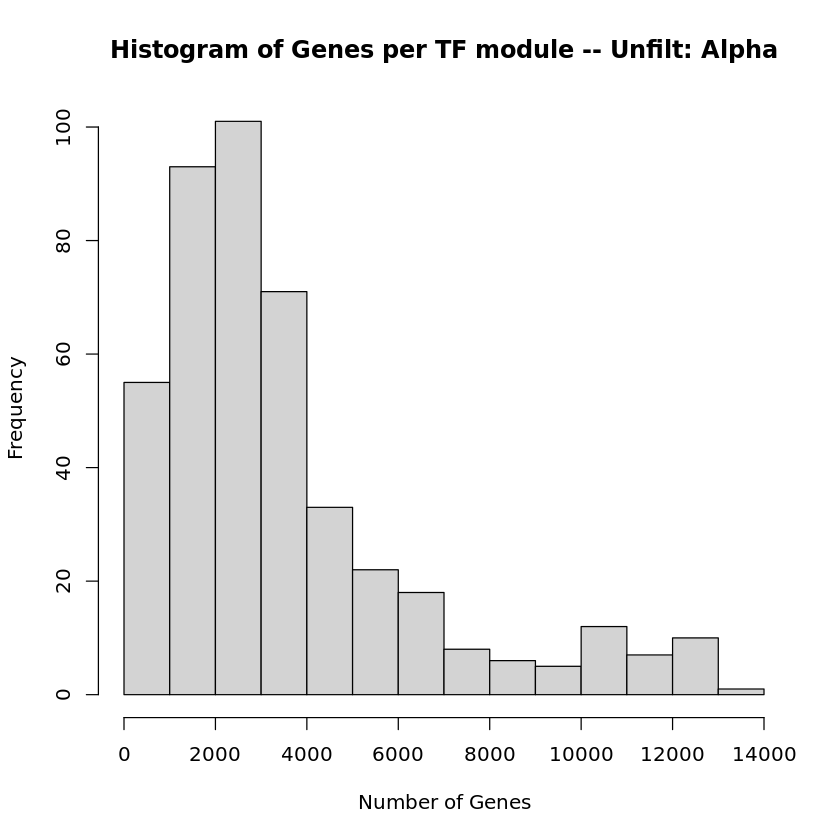

[1] 179
[1] 7198
[1] 2739.149
[1] "Beta"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Beta/"


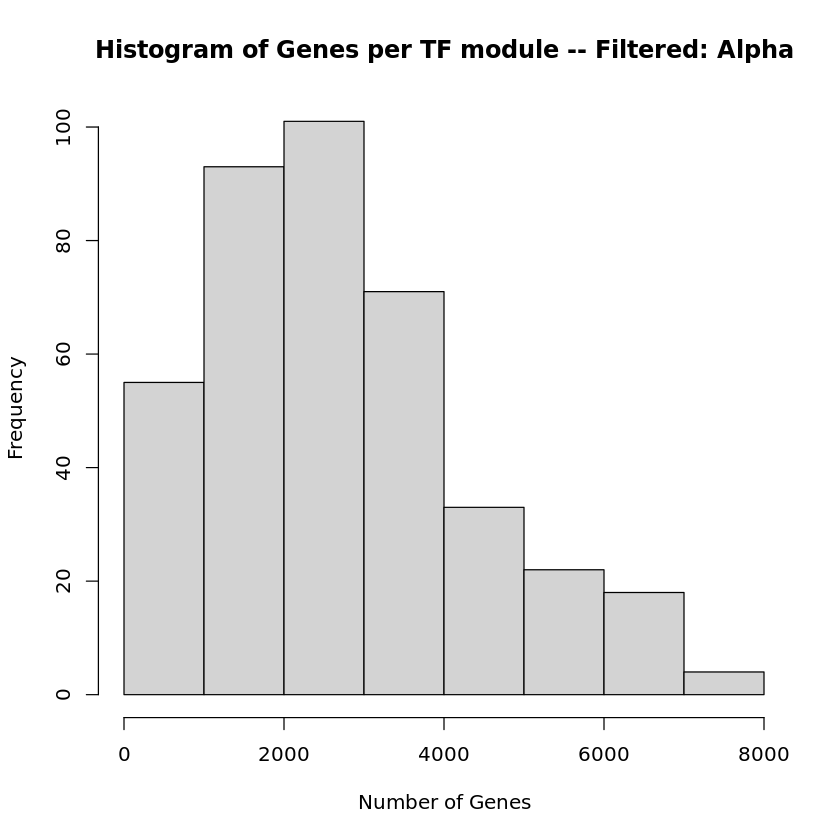

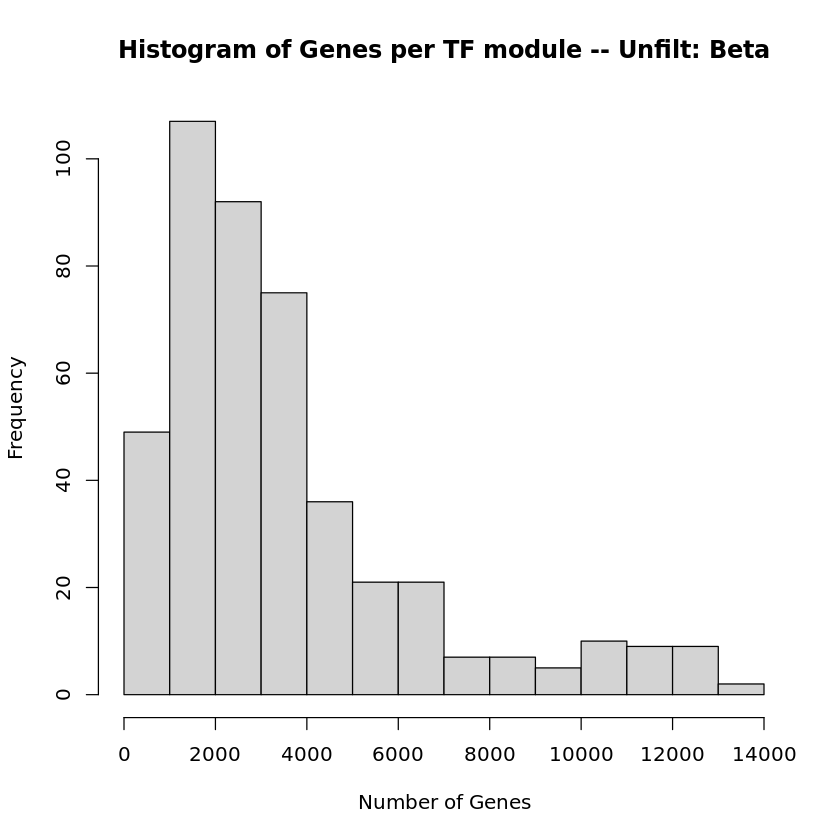

[1] 180
[1] 7322
[1] 2771.568
[1] "Ductal"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Ductal/"


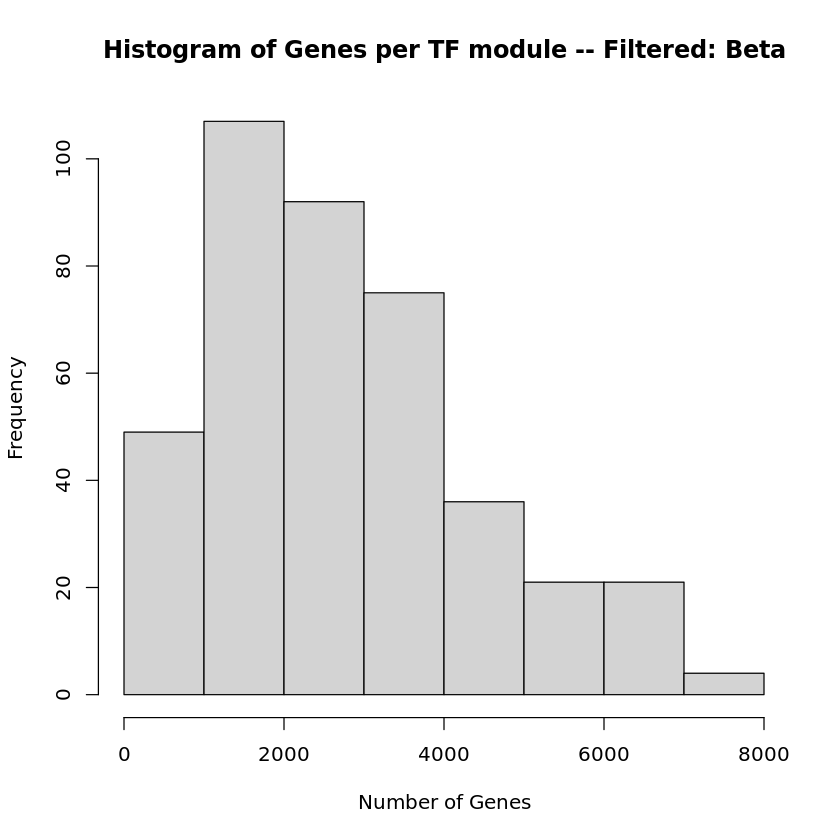

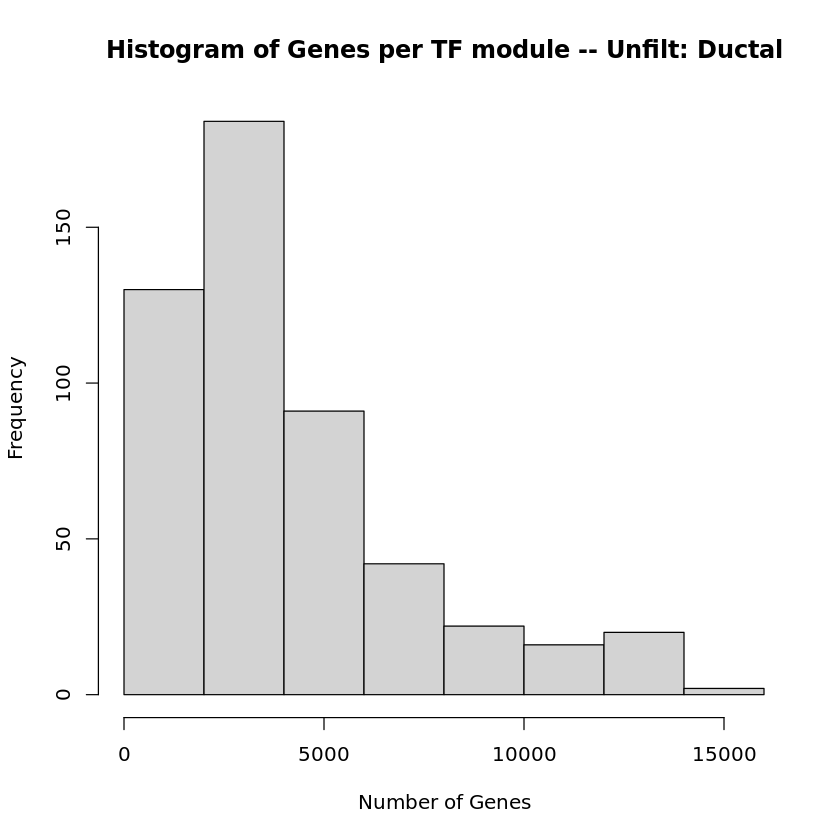

[1] 243
[1] 8489
[1] 3317.544
[1] "Endothelial"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Endothelial/"


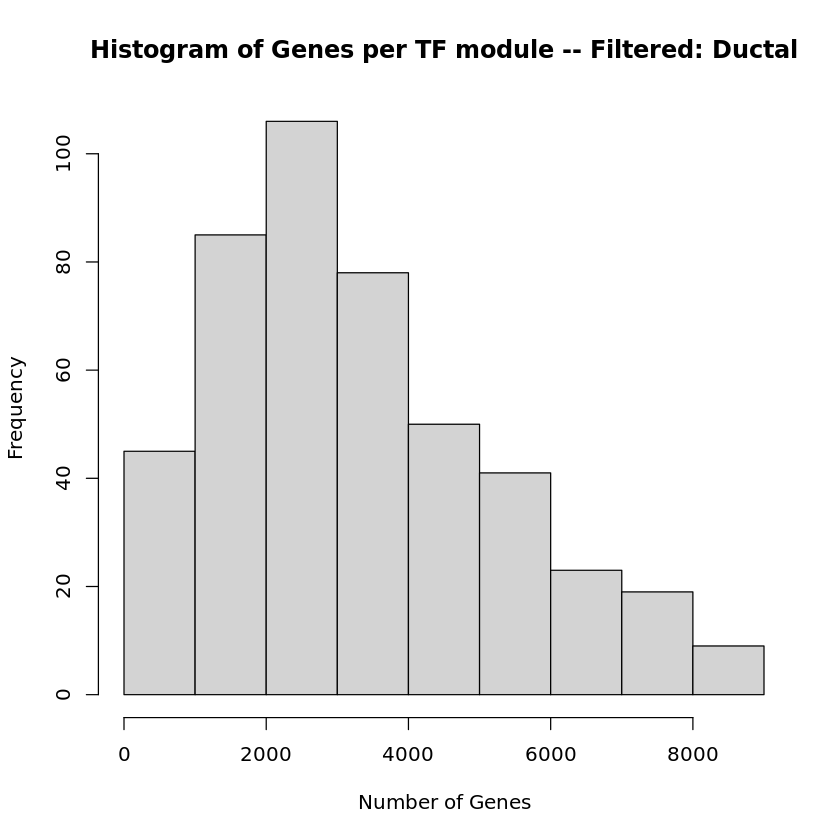

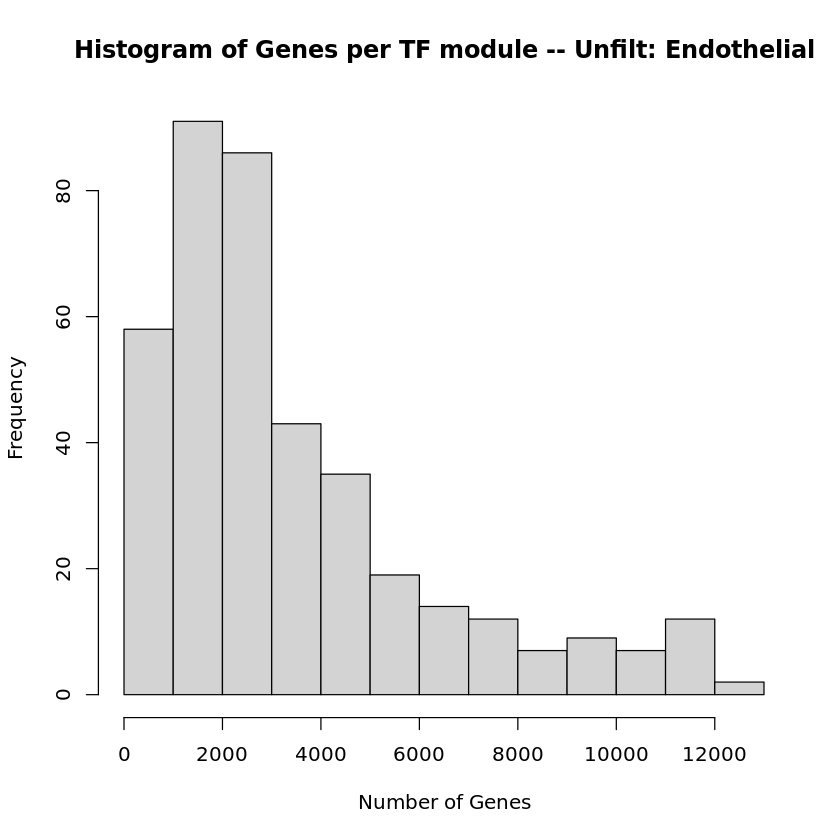

[1] 155
[1] 7832
[1] 2692.028
[1] "Macrophage"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Macrophage/"


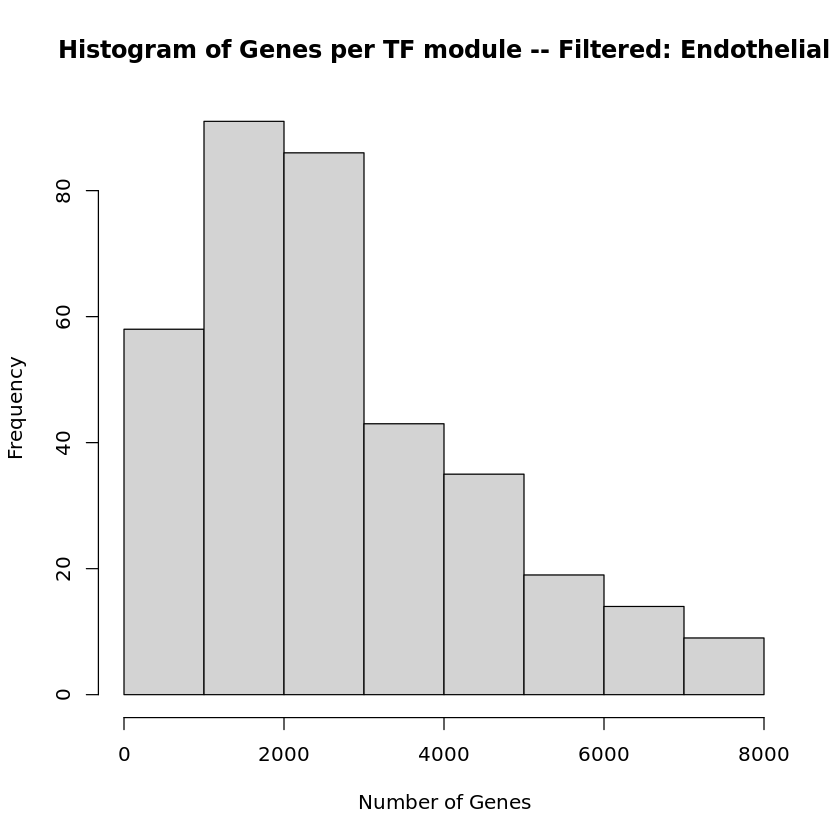

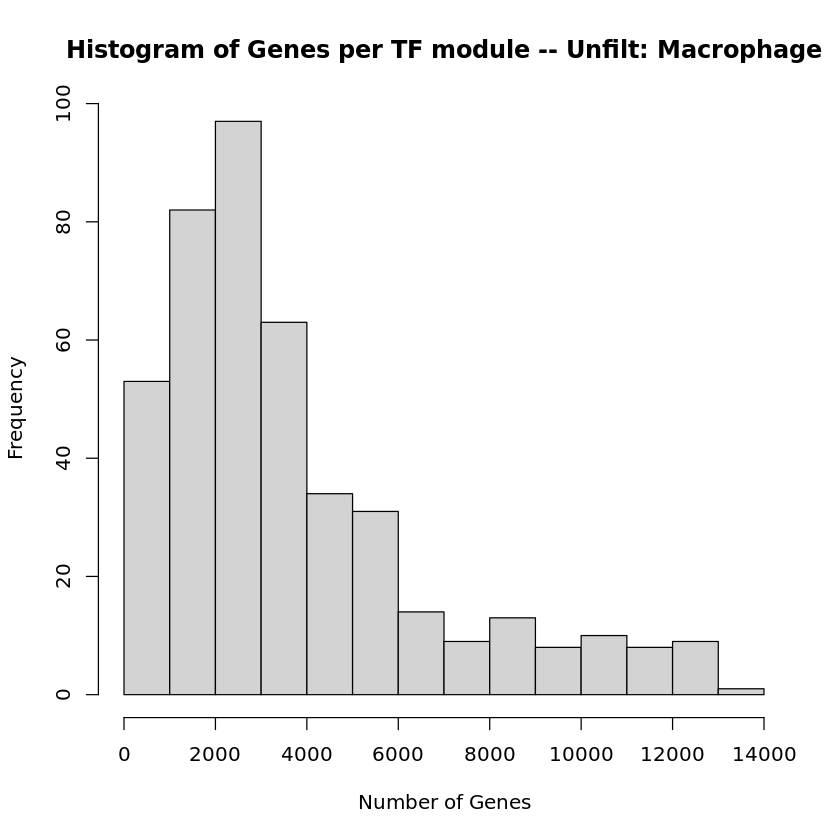

[1] 234
[1] 8576
[1] 2939.982
[1] "Quiescent_Stellate"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Quiescent_Stellate/"


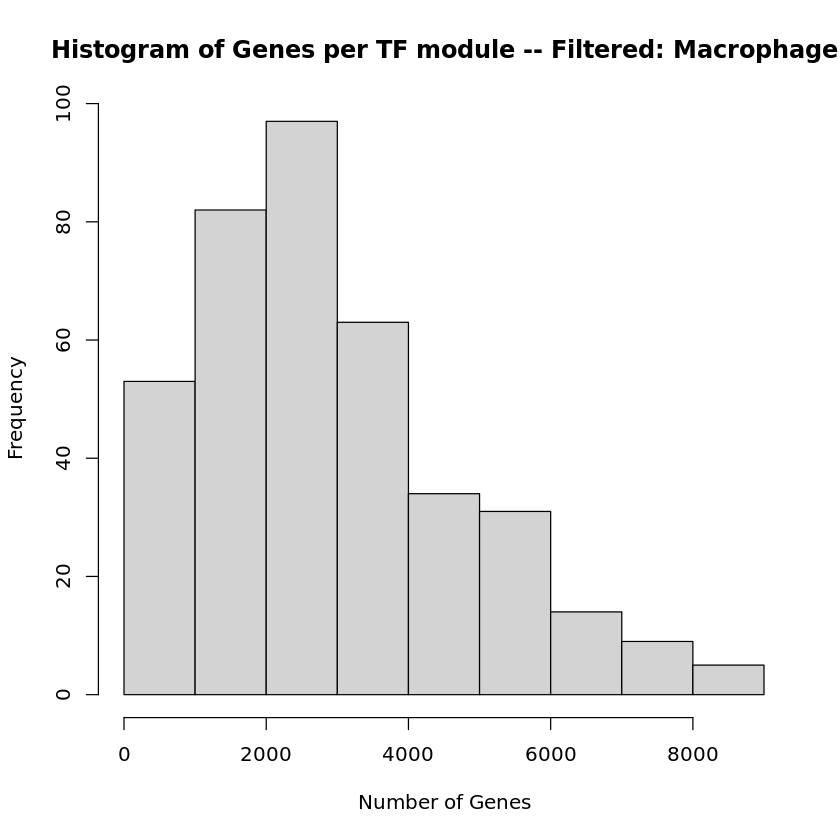

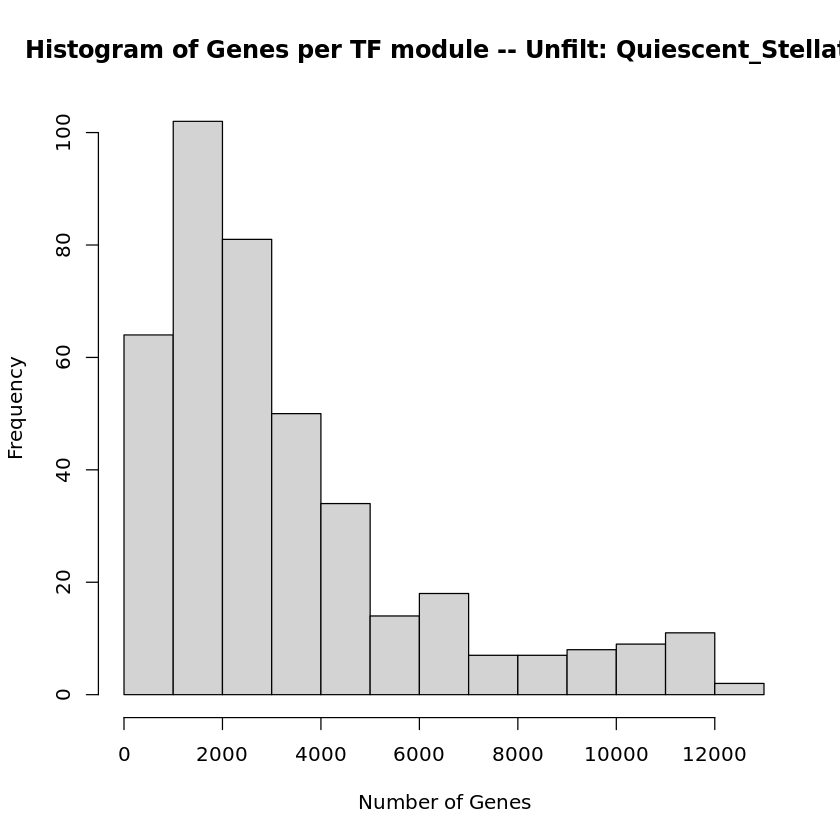

[1] 181
[1] 7168
[1] 2583.224
[1] "Tcells"
[1] "/nfs/lab/projects/nPOD/downstream_files/GRN/Tcells/"


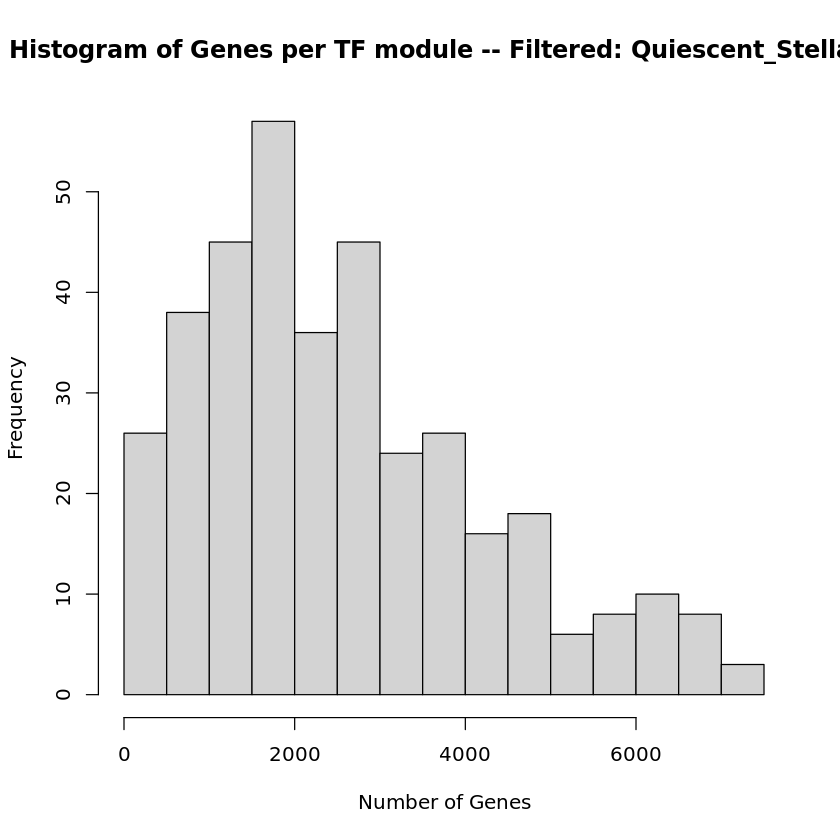

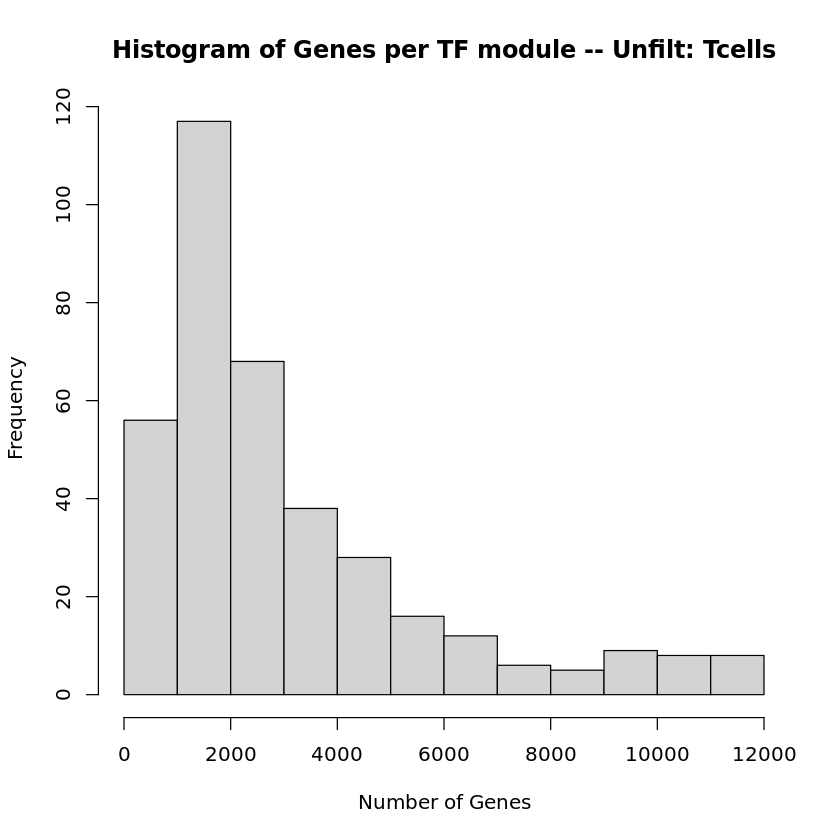

[1] 191
[1] 6857
[1] 2353.715


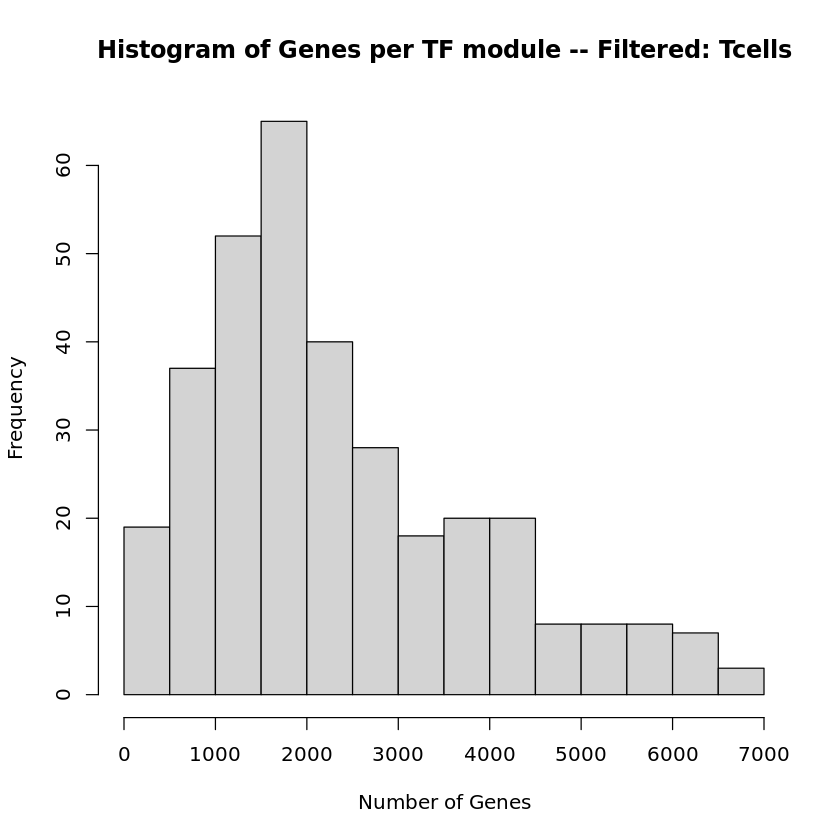

In [4]:
### removed B cells, Delta, lymph endo, mast 
cell_type_use = c('Acinar_1_2_6','Acinar_3','Acinar_4','Acinar_5','Activated_Stellate','Alpha','Beta','Ductal','Endothelial','Macrophage','Quiescent_Stellate','Tcells')

for (cell_num in 1:length(cell_type_use)) {
    print(cell_type_use[cell_num])
    mainDir <- '/nfs/lab/projects/nPOD/downstream_files/GRN'
    subDir <- paste0(cell_type_use[cell_num],'/')
    print(file.path(mainDir, subDir))
    #dir.create(file.path(mainDir, subDir))
    setwd(file.path(mainDir, subDir))
    beta_corr <- read.csv(paste0(cell_type_use[cell_num],'_TF_gene.csv'))
    TF_gene_only <- beta_corr[,c('TF','gene')]

    no_dups <- TF_gene_only [!duplicated(TF_gene_only[c(1,2)]),]
    dim(no_dups)

    tf_column <- no_dups[, 'TF']
    tf_counts <- table(tf_column)
    mean(tf_counts)
    hist(tf_counts, xlab = "Number of Genes", ylab = "Frequency",
         main = paste0("Histogram of Genes per TF module -- Unfilt: ",cell_type_use[cell_num]))


    #beta_corr[beta_corr$TF == 'PDX1',]

    Ten_per <- quantile(tf_counts, probs = seq(.1, .9, by = .1))[[1]]
    Ninety_per <- quantile(tf_counts, probs = seq(.1, .9, by = .1))[[9]]
    #tf_counts_perc_filt <- tf_counts[Ten_per < tf_counts &  tf_counts < Ninety_per]
    tf_counts_perc_filt <- tf_counts[tf_counts < Ninety_per]

    #quantile(tf_counts, probs = seq(.01, .9, by = .1))[[1]]

    beta_GRN_filt_GoodTFs <- beta_corr[beta_corr$TF %in% names(tf_counts_perc_filt),]
    head(beta_GRN_filt_GoodTFs)
    length(unique(beta_GRN_filt_GoodTFs$TF))

    #getwd()

    write.table(beta_GRN_filt_GoodTFs, file =paste0(cell_type_use[cell_num],'_GRN_filt_GoodTFs.txt'), sep='\t', quote = FALSE, col.names = TRUE, row.names = TRUE)



    TF_gene_only <- beta_GRN_filt_GoodTFs[,c('TF','gene')]
    no_dups <- TF_gene_only [!duplicated(TF_gene_only[c(1,2)]),]

    tf_column <- no_dups[, 'TF']
    tf_counts <- table(tf_column)
    mean(tf_counts)
    hist(tf_counts, xlab = "Number of Genes", ylab = "Frequency",
         main = paste0("Histogram of Genes per TF module -- Filtered: ",cell_type_use[cell_num]))

    print(min(tf_counts))
    print(max(tf_counts))
    print(mean(tf_counts))
    }

In [1]:
library(BSgenome.Hsapiens.UCSC.hg38)

Loading required package: BSgenome

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb

Loading required package: GenomicRanges

Loading required package: Biostrings

Loading 